In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , r2_score , mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor




In [5]:
import pandas as pd

df = pd.read_csv("data/train.csv")


df.head()
print(df.isnull().sum())
print(df.describe())
df.info()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea 

In [6]:
df.select_dtypes(include=np.number)
df.select_dtypes(include='object')
num_cols = df.select_dtypes(include=['int64' , "float64"]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


print(df.isnull().sum())

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64


C:\Users\mysel\AppData\Local\Temp\ipykernel_26512\250837134.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object')
C:\Users\mysel\AppData\Local\Temp\ipykernel_26512\250837134.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.ht

In [7]:
X = df.drop('SalePrice' , axis =1)
Y = df['SalePrice']

In [8]:
X.select_dtypes(include='object').columns
X = pd.get_dummies(X , drop_first=True)
X.dtypes

C:\Users\mysel\AppData\Local\Temp\ipykernel_26512\2537305811.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include='object').columns


Id                         int64
MSSubClass                 int64
LotFrontage              float64
LotArea                    int64
OverallQual                int64
                          ...   
SaleCondition_AdjLand       bool
SaleCondition_Alloca        bool
SaleCondition_Family        bool
SaleCondition_Normal        bool
SaleCondition_Partial       bool
Length: 245, dtype: object

In [9]:
X_train ,X_test ,Y_train ,Y_test = train_test_split(X ,Y , test_size=0.2 , random_state=42)
model = LinearRegression()
model.fit(X_train ,Y_train)
pre = model.predict(X_test)
pre[:10]

array([156441.38852364, 339187.42788376,  86610.65378859, 187116.25956569,
       320803.73856031,  64107.21804401, 254169.98510001, 145624.71308415,
        53010.11069718, 155793.97811051])

In [10]:
mae = mean_absolute_error(Y_test , pre)
mse = mean_squared_error(Y_test , pre)
r2 = r2_score(Y_test , pre)
print(f"MSE : {mse}\nMAE : {mae}\nR2_score : {r2}")

MSE : 1019680445.3135121
MAE : 20383.824122216545
R2_score : 0.8670616584262


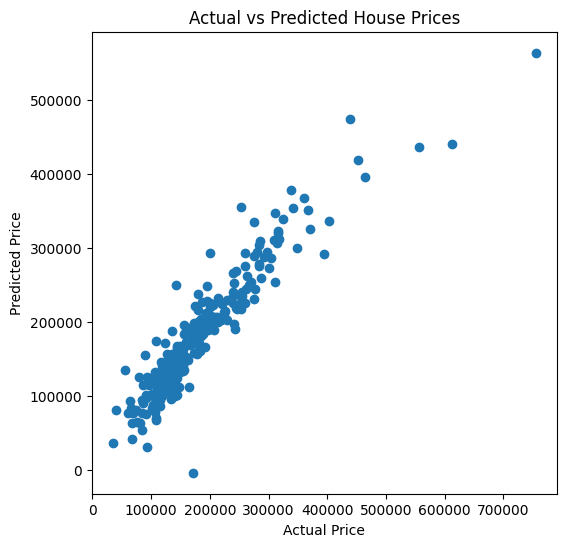

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, pre)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [12]:
comp = pd.DataFrame({
    "Actual" : Y_test.values,
    "predicited" : pre
})
comp[:10]

,Actual,predicited
0,154500,156441.388524
1,325000,339187.427884
2,115000,86610.653789
3,159000,187116.259566
4,315500,320803.738560
5,75500,64107.218044
6,311500,254169.985100
7,146000,145624.713084
8,84500,53010.110697
9,135500,155793.978111


In [13]:
dt = DecisionTreeRegressor()
dt.fit(X_train , Y_train)
pre_dt = dt.predict(X_test)
pre_dt[:10]
r2_dt = r2_score(Y_test , pre_dt)

print(r2)
print(r2_dt)

0.8670616584262
0.7669368702355963


In [14]:
rd = RandomForestRegressor()
rd.fit(X_train , Y_train)
pre_rd = rd.predict(X_test)
r2_rd = r2_score(Y_test , pre_rd)


print(r2_rd)


0.8885222642630209


In [15]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2 Score": [r2, r2_dt, r2_rd]
})

print(comparison)

               Model  R2 Score
0  Linear Regression  0.867062
1      Decision Tree  0.766937
2      Random Forest  0.888522


In [16]:
sample = X_test.iloc[[0]]
prediction = model.predict(sample)
print("Predicted Price:", prediction[0])
print("Actual Price:", Y_test.iloc[0])

Predicted Price: 156441.3885236429
Actual Price: 154500


In [17]:
sample1 = X_test.iloc[[1]]
p = model.predict(sample1)
print(f"predicted : {p[0]}")
print(f"Actual : {Y_test.iloc[1]}")

predicted : 339187.42788376403
Actual : 325000


In [18]:
for i in range(10):
    sample = X_test.iloc[[i]]
    predicted = model.predict(sample)[0]
    actual = Y_test.iloc[i]

    print(f"House {i+1}")
    print(f"Actual    : {actual}")
    print(f"Predicted : {predicted:.2f}")
    print("-" * 30)

House 1
Actual    : 154500
Predicted : 156441.39
------------------------------
House 2
Actual    : 325000
Predicted : 339187.43
------------------------------
House 3
Actual    : 115000
Predicted : 86610.65
------------------------------
House 4
Actual    : 159000
Predicted : 187116.26
------------------------------
House 5
Actual    : 315500
Predicted : 320803.74
------------------------------
House 6
Actual    : 75500
Predicted : 64107.22
------------------------------
House 7
Actual    : 311500
Predicted : 254169.99
------------------------------
House 8
Actual    : 146000
Predicted : 145624.71
------------------------------
House 9
Actual    : 84500
Predicted : 53010.11
------------------------------
House 10
Actual    : 135500
Predicted : 155793.98
------------------------------


In [19]:


joblib.dump(model, "models/house_price_model.pkl")

['models/house_price_model.pkl']

In [20]:
comp = pd.DataFrame({
    "Actual" : Y_test.values,
    "Predicted" : pre
})
comp[:10]

,Actual,Predicted
0,154500,156441.388524
1,325000,339187.427884
2,115000,86610.653789
3,159000,187116.259566
4,315500,320803.738560
5,75500,64107.218044
6,311500,254169.985100
7,146000,145624.713084
8,84500,53010.110697
9,135500,155793.978111


In [21]:
for i in range(15):
    sample = X_test.iloc[[i]]
    pred = model.predict(sample)[0]
    act = Y_test.iloc[i]


    print(f"House: {i+1}")
    print(f"Actual : {act}")
    print(f"Predicted: {pred:.2f}")
    print("+"*20)

House: 1
Actual : 154500
Predicted: 156441.39
++++++++++++++++++++
House: 2
Actual : 325000
Predicted: 339187.43
++++++++++++++++++++
House: 3
Actual : 115000
Predicted: 86610.65
++++++++++++++++++++
House: 4
Actual : 159000
Predicted: 187116.26
++++++++++++++++++++
House: 5
Actual : 315500
Predicted: 320803.74
++++++++++++++++++++
House: 6
Actual : 75500
Predicted: 64107.22
++++++++++++++++++++
House: 7
Actual : 311500
Predicted: 254169.99
++++++++++++++++++++
House: 8
Actual : 146000
Predicted: 145624.71
++++++++++++++++++++
House: 9
Actual : 84500
Predicted: 53010.11
++++++++++++++++++++
House: 10
Actual : 135500
Predicted: 155793.98
++++++++++++++++++++


House: 11
Actual : 145000
Predicted: 144219.42
++++++++++++++++++++
House: 12
Actual : 130000
Predicted: 109887.96
++++++++++++++++++++
House: 13
Actual : 81000
Predicted: 63149.19
++++++++++++++++++++
House: 14
Actual : 214000
Predicted: 232211.07
++++++++++++++++++++
House: 15
Actual : 181000
Predicted: 171343.48
++++++++++++++++++++
